In [152]:
import numpy as np
import matplotlib.pyplot as plt
import lmdb
import pickle
import statistics


In [20]:
import numpy as np

# 读取 npz 文件中的数据
data = np.load('/home/liud/Documents/code/ocp/results/2024-09-26-10-48-32/is2re_predictions.npz')

# 提取 ids1, ids2 和 energy
ids1 = data['ids1']
ids2 = data['ids2']
energy = data['energy']

# 将 ids1 和 ids2 转换为数值
ids1_numeric = ids1.astype(int)
ids2_numeric = ids2.astype(int)

# 将 ids1 和 ids2 合并为一个键，用于排序
combined_ids = list(zip(ids1_numeric, ids2_numeric))

# 创建一个索引列表，先根据 ids1_numeric 排序，然后再根据 ids2_numeric 排序
sorted_indices = np.lexsort((ids2_numeric, ids1_numeric))

# 根据排序后的索引获取排序后的 energy 列表
energy_list = [energy[i] for i in sorted_indices]

print(energy_list)
print(len(energy_list))


NpzFile '/home/liud/Documents/code/ocp/results/2024-10-02-11-16-16/is2re_predictions.npz' with keys: ids1, energy
['1000157' '1001730' '1002561' ... '996620' '998315' '999808']
[-0.6349112 -4.0437818 -3.0903723 ... -2.3842206 -2.5141053 -2.4214704]


In [23]:
import lmdb
import pickle
import numpy as np

# 打开 LMDB 文件
env = lmdb.open('/media/liud/Liud_FX2T/dataset/Cu_self/test_1', readonly=True)

# 列表用于存储 (sid, fid, y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid, fid 和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        data_list.append((info.sid, info.fid, info.y))

# 关闭 LMDB 文件
env.close()

# 将数据转换为 numpy 数组以便于排序
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('fid', 'i4'), ('y', 'f8')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid', 'fid'])

# 提取排序后的 sid、fid 和 y 值列表
sid_list = sorted_data_array['sid'].tolist()
fid_list = sorted_data_array['fid'].tolist()
test_list = sorted_data_array['y'].tolist()

# print("sid:", sid_list)
# print("fid:", fid_list)
print("y:", test_list)
print("Length:", len(test_list))


sid: [9326, 22276, 26051, 42374, 50884, 56843, 62359, 68916, 71567, 76151, 78060, 80161, 94196, 101006, 105270, 130006, 141849, 153807, 163939, 187296, 195873, 218400, 218846, 223033, 244680, 245382, 247498, 253785, 254511, 272743, 281564, 315816, 336054, 342370, 344219, 348193, 355692, 359192, 362713, 363569, 384991, 389443, 398514, 398555, 398736, 416197, 416285, 419783, 422331, 423046, 436210, 442952, 443310, 443628, 448396, 450415, 454472, 456198, 457684, 458187, 459266, 459746, 460516, 463973, 464739, 465589, 466391, 470239, 470685, 470892, 472306, 472733, 474276, 476030, 476516, 478744, 481107, 482628, 483094, 484183, 484418, 488240, 488728, 489090, 491690, 492728, 493277, 493321, 494327, 495912, 498978, 499532, 501451, 501874, 504995, 506986, 508290, 510326, 511241, 512970, 514021, 515529, 515533, 516855, 517995, 518695, 518752, 520210, 521773, 524253, 525112, 525975, 526334, 528406, 530942, 531128, 531683, 532667, 534486, 537767, 540104, 540554, 541214, 543910, 544279, 546760, 

In [155]:
efficient = [abs((t - e) / t)  for e, t in zip(energy_list, test_list)]

In [156]:
# efficient
statistics.median(efficient)

0.6324449546428

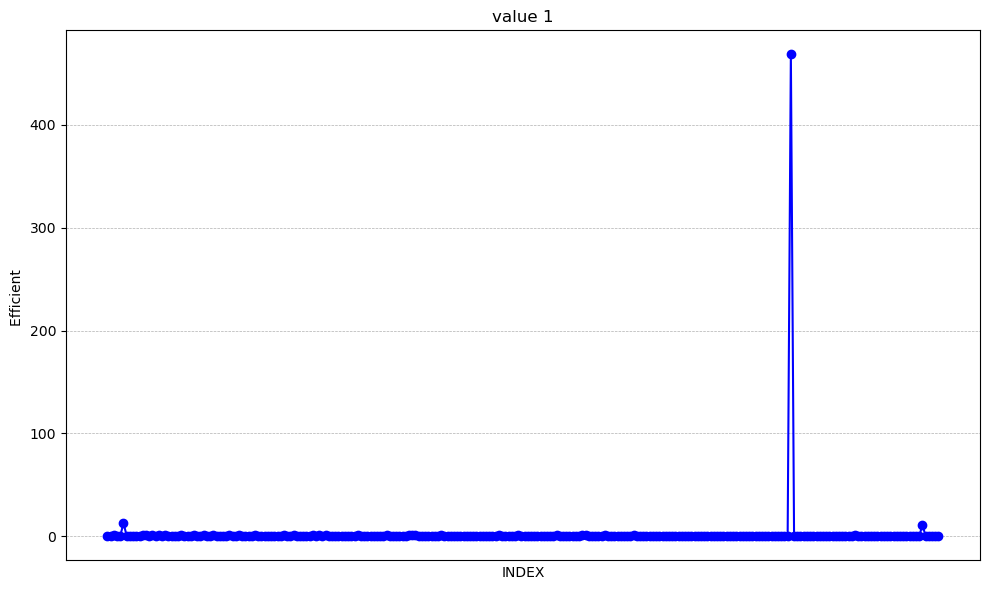

In [157]:
x = list(range(1, len(efficient) + 1))

plt.figure(figsize=(10, 6))  # 设置图像大小
plt.plot(x, efficient, marker='o', linestyle='-', color='b')  # 绘制折线图

plt.xlabel("INDEX")  # 设置横坐标标签
plt.ylabel("Efficient ")     # 设置纵坐标标签
plt.title("value 1")  # 设置图像标题


plt.xticks([])  # 设置横坐标刻度为正整数

plt.grid(True, which='both', linestyle='--', linewidth=0.5)  # 添加网格线
plt.tight_layout()  # 调整图像布局

plt.show()  # 显示图像

In [158]:
count_below_0_4 = sum(1 for value in efficient if value < 1)

# 计算比例
ratio = count_below_0_4 / len(efficient)
ratio

0.9846153846153847

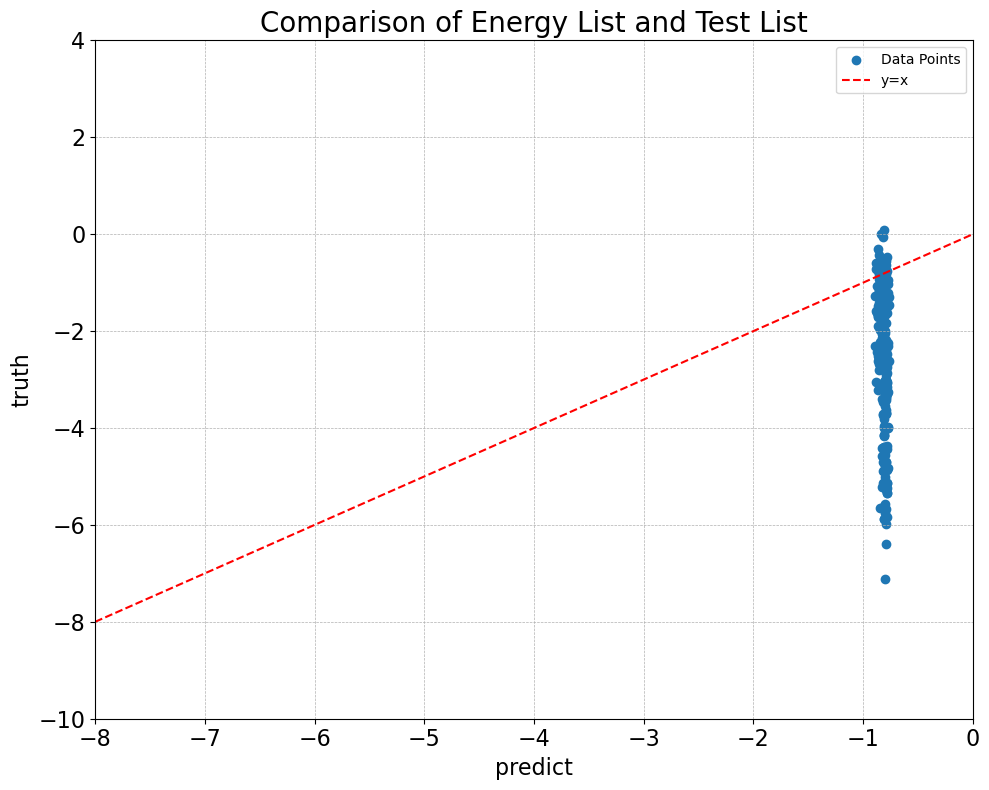

In [159]:
import matplotlib.pyplot as plt
import numpy as np

# 创建横坐标和纵坐标
x = energy_list
y = test_list

plt.figure(figsize=(10, 8))  # 设置图像大小

# 绘制散点图以检查线性分布
plt.scatter(x, y, label='Data Points', marker='o')

# 添加 y=x 的虚线
# min_val = min(min(x), min(y))
# max_val = max(max(x), max(y))
min_val = -8
max_val = 0
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='r', label='y=x')

plt.xlim(-8, 0)
plt.ylim(-10, 4)
# 添加标题和图例
plt.title('Comparison of Energy List and Test List', fontsize=20)
plt.xlabel('predict', fontsize=16)
plt.ylabel('truth', fontsize=16)
plt.legend()

plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)

# 显示图形
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()



In [160]:
difference = [abs(e - t) for e, t in zip(energy_list, test_list)]
filtered_difference = [d for d in difference if d <= 0.3]
len(filtered_difference)
# 输出结果
# print(difference)

42

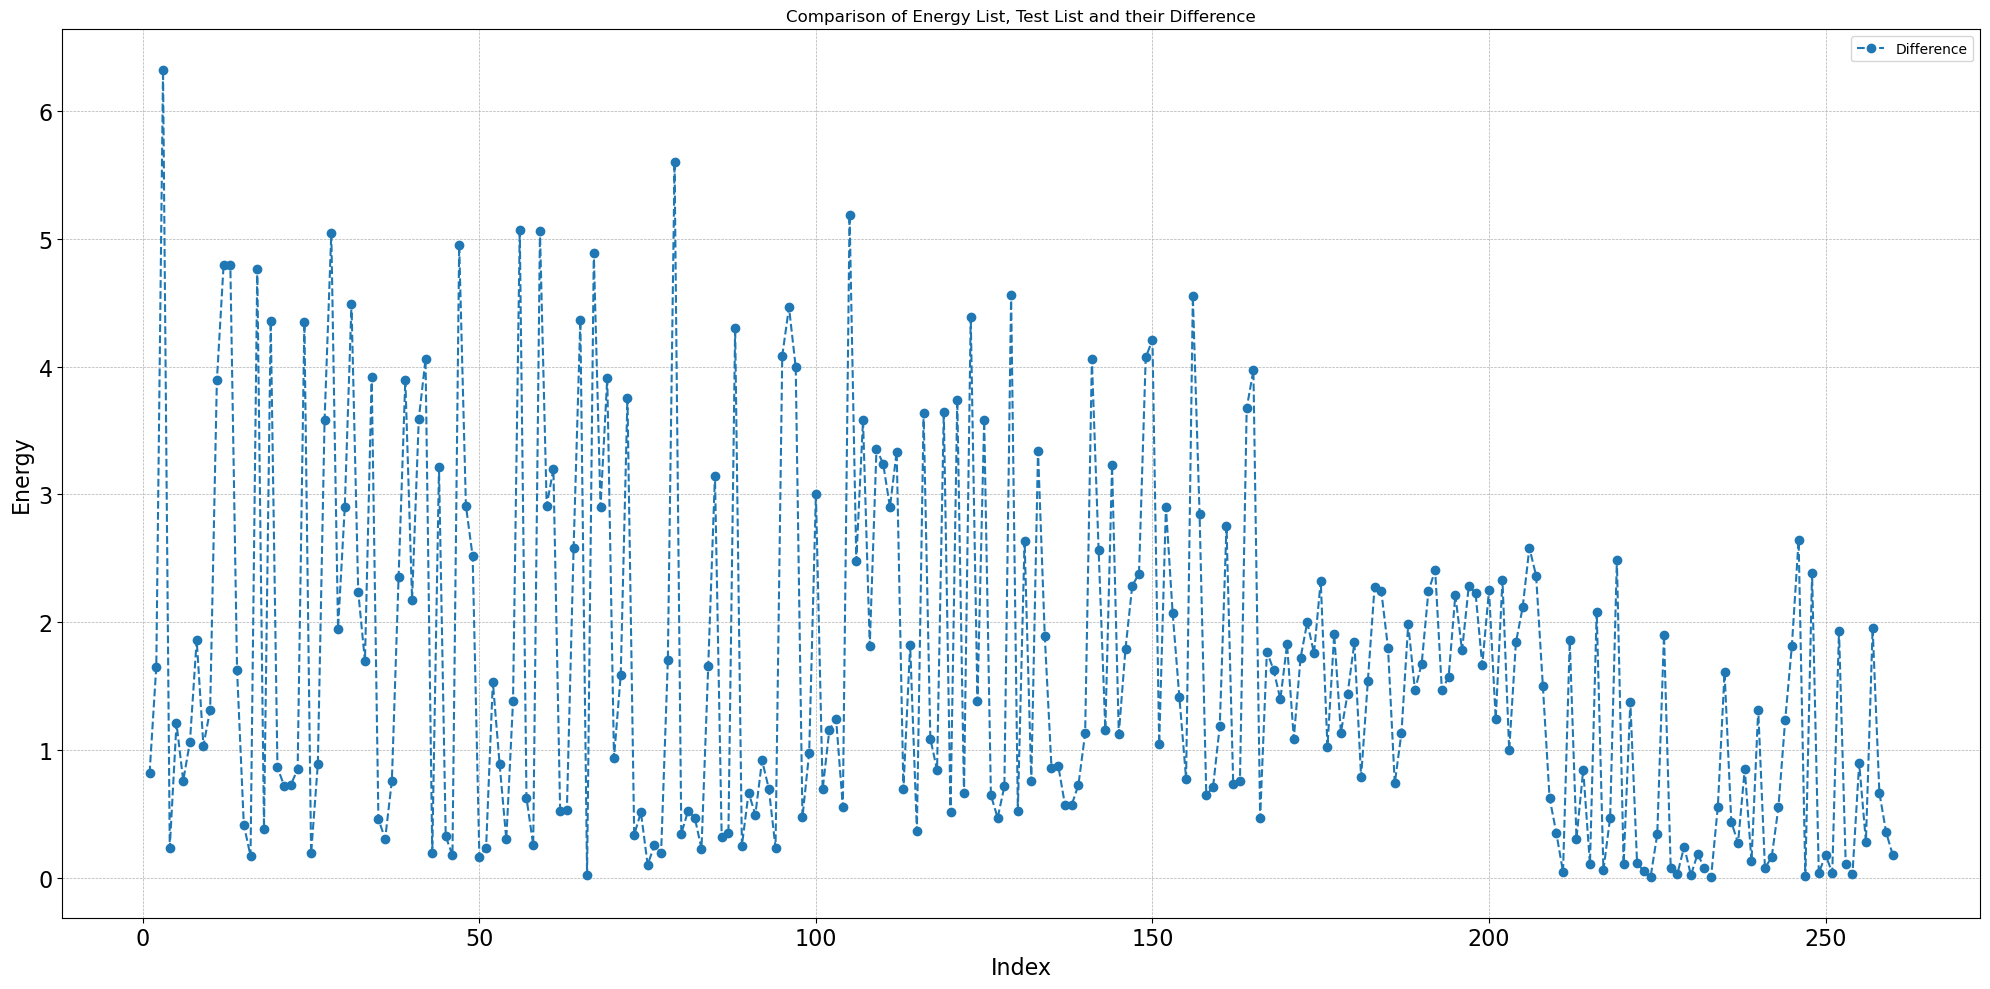

In [161]:
x = range(1, len(energy_list) + 1)
plt.figure(figsize=(20, 10))  # 设置图像大小
# 做差值
plt.plot(x, difference, label='Difference', marker='o', linestyle='--')
plt.title('Comparison of Energy List, Test List and their Difference')
plt.xlabel('Index', fontsize=16)
plt.ylabel('Energy', fontsize=16)
plt.legend()

plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)

# 显示图形
plt.tight_layout()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

In [162]:
# def mean_absolute_error(data_list):
#     # 计算平均绝对误差
#     mae = sum(data_list) / len(data_list)
#     return mae
# 
# # 示例
# print(mean_absolute_error(difference))

import numpy as np

def calculate_errors(data_list):
    # 计算平均绝对误差 (MAE)
    mae = np.mean(np.abs(data_list))
    
    # 计算均方误差 (MSE)
    mse = np.mean(np.square(data_list))
    
    # 计算均方根误差 (RMSE)
    rmse = np.sqrt(mse)
    
    return mae, mse, rmse

mae, mse, rmse = calculate_errors(difference)

print(f"MAE: {mae}") 
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 1.6811039551755078
MSE: 4.864437075914864
RMSE: 2.2055468881696587


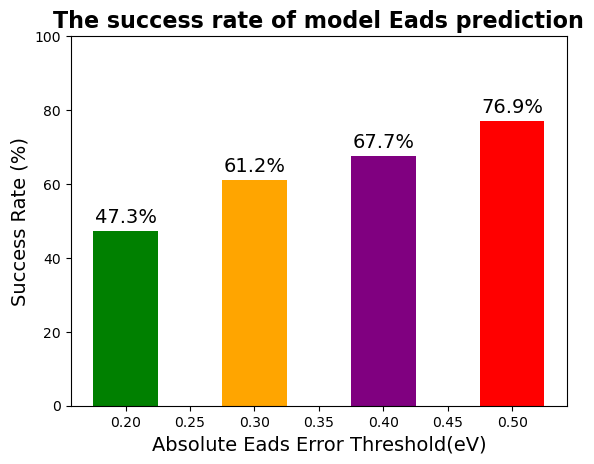

In [147]:
# n_difference = sum(1 for value in difference if value < 0.3)
# 
# # 计算比例
# ratio_diff = n_difference / len(difference)
# ratio_diff


# 定义不同的绝对误差阈值
thresholds = [0.2, 0.3, 0.4, 0.5]

# 计算每个阈值下的成功率
success_rates = [sum(1 for value in difference if value < threshold) / len(difference) for threshold in thresholds]

# 转换为百分比
success_rates_percentage = [rate * 100 for rate in success_rates]

# 定义柱子的颜色
colors = ['green', 'orange', 'purple','red']

# 创建条形图
fig, ax = plt.subplots()
bars = ax.bar(thresholds, success_rates_percentage, color=colors, width=0.05)

# 添加数据标签
for bar, rate in zip(bars, success_rates_percentage):
    height = bar.get_height()
    ax.annotate(f'{rate:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=14)

# 设置标题和标签
ax.set_title('The success rate of model Eads prediction', fontsize=16, fontweight='bold')
ax.set_xlabel('Absolute Eads Error Threshold(eV)', fontsize=14)
ax.set_ylabel('Success Rate (%)', fontsize=14)
ax.set_ylim(0, 100)

# 显示图形
plt.show()

In [150]:
import lmdb
import pickle
import numpy as np

# 读取 npz 文件中的数据
data = np.load('/home/zjy/code/mycode/ocp/data_analyse/2024-07-22-09-04-00/is2re_predictions.npz')

# 提取 ids1, ids2 和 energy
ids1 = data['ids1']
ids2 = data['ids2']
energy = data['energy']

# 将 ids1 和 ids2 转换为数值
ids1_numeric = ids1.astype(int)
ids2_numeric = ids2.astype(int)

# 将 ids1 和 ids2 合并为一个键，用于排序
combined_ids = list(zip(ids1_numeric, ids2_numeric))

# 创建一个索引列表，先根据 ids1_numeric 排序，然后再根据 ids2_numeric 排序
sorted_indices = np.lexsort((ids2_numeric, ids1_numeric))

# 根据排序后的索引获取排序后的 energy 列表
sorted_energy = energy[sorted_indices]

# 打开 LMDB 文件以读取数据
env = lmdb.open('/home/zjy/code/mycode/ocp/test_data/all_CNN/test/', readonly=True)

# 列表用于存储 (sid, fid, y) 元组
data_list = []

# 从 LMDB 文件中读取数据并提取 sid, fid 和 y 值
with env.begin(write=False) as txn:
    cursor = txn.cursor()
    for key, value in cursor:
        info = pickle.loads(value)
        sid = info.sid
        fid = info.fid
        y = info.y
        data_list.append((sid, fid, y, key, value))

# 将 data_list 转换为 numpy 数组
data_array = np.array(data_list, dtype=[('sid', 'i4'), ('fid', 'i4'), ('y', 'f8'), ('key', 'O'), ('value', 'O')])

# 按照 sid 和 fid 对 data_array 进行排序
sorted_data_array = np.sort(data_array, order=['sid', 'fid'])

# 提取排序后的 y 列表以及 key 和 value
sorted_y = sorted_data_array['y']
sorted_keys = sorted_data_array['key']
sorted_values = sorted_data_array['value']

# 筛选出符合条件的数据
filtered_data = []

for i in range(len(sorted_y)):
    energy = sorted_energy[i]  # 获取对应的 energy
    y = sorted_y[i]
    key = sorted_keys[i]
    value = sorted_values[i]
    
    # 判断 energy 和 y 的绝对差值是否小于 0.35
    if 0.5 < abs(y - energy) < 0.7:
        filtered_data.append((key, value))  # 保存符合条件的键值对

# 关闭 LMDB 文件
env.close()

# 打开一个新的 LMDB 文件以存储筛选后的数据
env_new = lmdb.open('/home/zjy/code/mycode/ocp/test_data/all_CNN/test/test_050_070', map_size=int(1e12))

with env_new.begin(write=True) as txn_new:
    for new_key, (old_key, value) in enumerate(filtered_data):
        new_key_bytes = str(new_key).encode('ascii')  # 将新键转换为字节类型
        txn_new.put(new_key_bytes, value)  # 使用新键存储

# 关闭新的 LMDB 文件
env_new.close()

print(f"Filtered {len(filtered_data)} entries and stored in the new LMDB file with sequential keys.")


Filtered 99 entries and stored in the new LMDB file with sequential keys.
